In [3]:
import networkx as nx

In [5]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project")  # adjust if your notebook is nested differently
from functions_v2 import *

In [7]:
edges = [
    (0,1), (1,2), (0,2), (2,3), (3,4), (4,5), (3,5), (5,6),
    (6,7), (7,8), (8,9), (9,10), (10,11), (9,11), (11,12), (12,13), (13,14),
]
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
n_vertices = 15

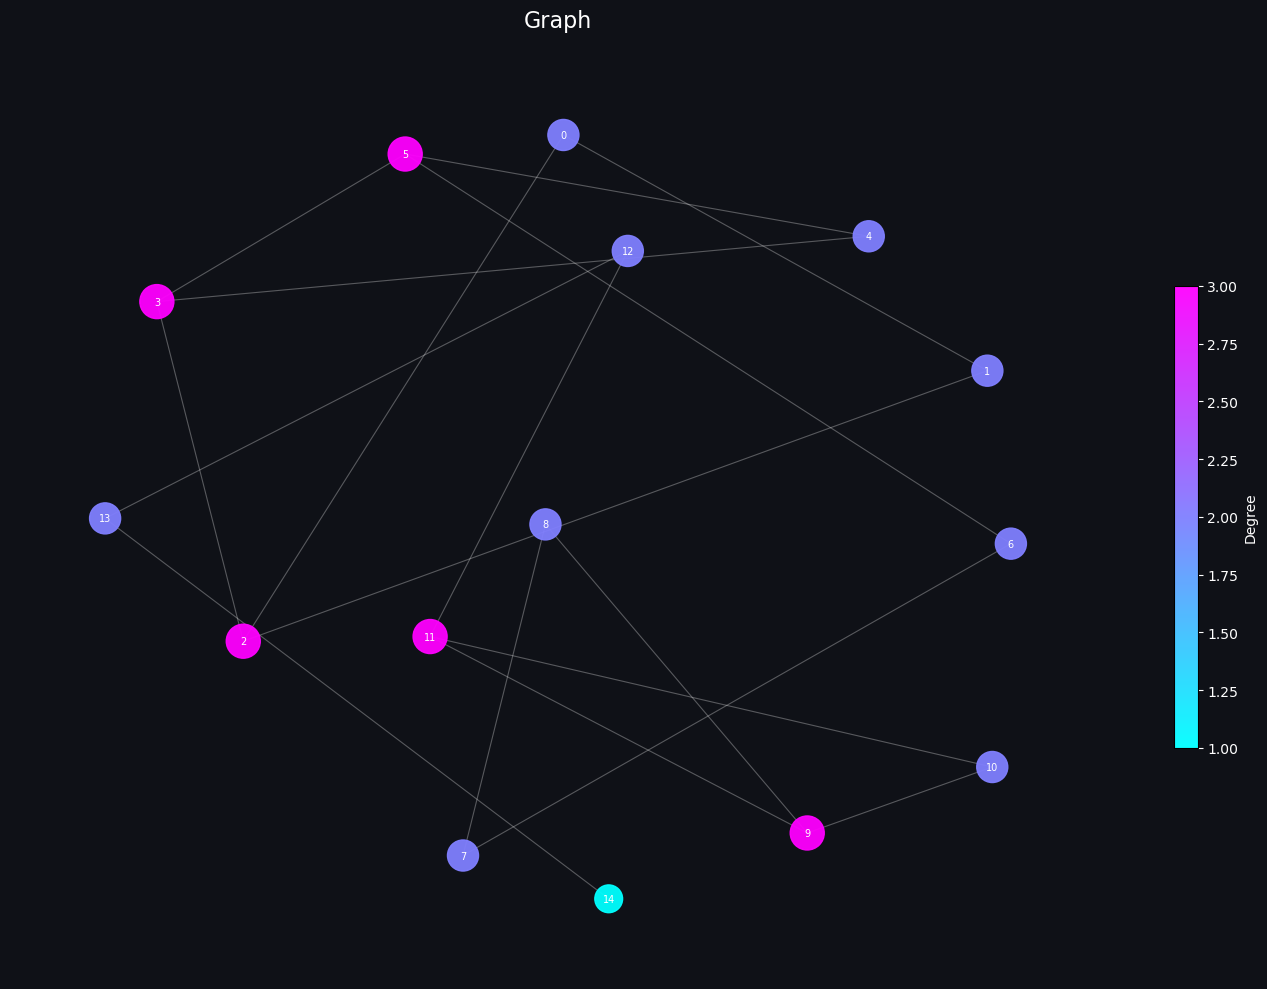

In [9]:
visualize_graph_2d(edges, n_vertices)

In [23]:
# try different values of k_hop - 1,2,3 and see its effect on boundary_fraction
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=0)

In [25]:
print("gamma_in:", gamma_in, "degrees:", [G_nx.degree(v) for v in gamma_in])
print("gamma_out:", gamma_out, "degrees:", [G_nx.degree(v) for v in gamma_out])
print("boundary_fraction:", (len(gamma_in)+len(gamma_out))/n_vertices)

gamma_in: [14] degrees: [1]
gamma_out: [1] degrees: [2]
boundary_fraction: 0.13333333333333333


#### Observations regarding k_hop
- pointing out that deciding k_hop (size of the neighborhood of v and w) is experimental and should be set such that we are getting a comfortably small fraction of graph as boundary
- because if the boundary is too large, we get a small fraction as interior nodes

In [33]:
gamma_in_set = set(gamma_in)
gamma_out_set = set(gamma_out)
boundary_set = gamma_in_set | gamma_out_set

aggregate_of = {}
agg_sizes = {}
agg_has_gamma_in = {}
agg_has_gamma_out = {}
next_agg_id = 0